In [26]:
# %pip install xgboost
# Cell 1: Imports
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import roc_auc_score, precision_score, recall_score, ndcg_score
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

# Load data

In [3]:
candidates = pd.read_csv('candidates.csv')
candidates.head(3)

,Unnamed: 0,ISBN,Title,Author,Year,Publisher,synopsis,subjects,genres,language,pages,binding,image_url,overview,similarity_score,read
0,9705,019282760X,Pride and Prejudice (World's Classics),Jane Austen,1990,Oxford University Press,When Elizabeth Bennet first meets eligible bac...,BRITISH AND IRISH FICTION (FICTIONAL WORKS BY ...,BRITISH AND IRISH FICTION (FICTIONAL WORKS BY ...,en,351.0,Paperback,https://images.isbndb.com/covers/1753385348225...,NaN,0.900964,True
1,11123,0192833553,Pride and Prejudice (Oxford World's Classics),Jane Austen,1998,Oxford University Press,"From its opening sentence, Jane Austen's most ...",BRITISH AND IRISH FICTION (FICTIONAL WORKS BY ...,BRITISH AND IRISH FICTION (FICTIONAL WORKS BY ...,en,410.0,Paperback,https://images.isbndb.com/covers/1759332348225...,NaN,0.827422,False
2,6241,0451525884,Pride and Prejudice,Jane Austen,1996,Signet Book,'I must confess that I think her as delightful...,"Fiction, Classics, Literary","Fiction, Classics, Literary",en,324.0,Paperback,https://images.isbndb.com/covers/2062396348234...,NaN,0.811944,False


In [5]:
book_embeddings = np.load('book_embeddings.npy')
print(book_embeddings.shape)
user_embedding = np.load('user_embedding.npy')
print(user_embedding.shape)

(14610, 384)
(384,)


In [ ]:
user_profile = {
    "favorite_genres": [
        "Fantasy",
        "Action & Adventure",
        "Women Sleuths"
    ],
    "favorite_subjects": [
        "Romance",
        "Espionage",
        "Medical"
    ],
    "preferred_year_range": (2000, 2025),
    "language" : "en",
    "user_read_history": [
        (9705, 5.0),
    ]
}

user_df = pd.DataFrame([{
    "favorite_genres": "|".join(user_profile["favorite_genres"]),
    "favorite_subjects": "|".join(user_profile["favorite_subjects"]),
    "preferred_year_start": user_profile["preferred_year_range"][0],
    "preferred_year_end": user_profile["preferred_year_range"][1],
    "age": user_profile["age"],
    "language": user_profile["language"],
    "user_read_history": str(user_profile["user_read_history"])
}])

display(user_df)

,favorite_genres,favorite_subjects,preferred_year_start,preferred_year_end,age,language,user_read_history
0,Fantasy|Action & Adventure|Women Sleuths,Romance|Espionage|Medical,2000,2025,35,en,"[(9705, 5.0)]"


# Helper Functions

In [ ]:
def overlap_count(a, b):
    return len(set(a).intersection(set(b)))

# Feature Engeneering

In [ ]:
from sklearn.metrics.pairwise import cosine_similarity

def build_features(df, u_profile, u_embedding, b_embeddings):
    features = []

    for _, row in df.iterrows():
        f = {}

        # Embedding affinity
        f["embedding_cosine"] = row['similarity_score']

        # Overlap features
        f["genre_overlap"] = overlap_count(
            u_profile["favorite_genres"][0].split("|"),
            row["genres"].split("|")
        )

        f["subject_overlap"] = overlap_count(
            u_profile["favorite_subjects"][0].split("|"),
            row["subjects"].split("|")
        )

        # Year proximity
        f["year_distance"] = abs(row["Year"] - (u_profile["preferred_year_start"] + u_profile["preferred_year_end"]) / 2)

        # Language match
        f["language_match"] = int(row["language"] == u_profile["language"][0])

        # Dense embeddings
        for i, v in enumerate(b_embeddings):
            f[f"book_emb_{i}"] = v

        features.append(f)

    return pd.DataFrame(features)

# Scoring the books

Defining scoring weights

In [ ]:
SCORING_WEIGHTS = {
    "embedding_cosine": 0.4,    # Semantic similarity from embeddings
    "genre_overlap": 0.2,       # Genre match importance
    "subject_overlap": 0.2,     # Subject match importance
    "language_match": 0.1,      # Language preference
    "year_proximity": 0.1,      # Publication year relevance
}

print("Scoring Weights:")
for k, v in SCORING_WEIGHTS.items():
    print(f"  {k}: {v:.0%}")

Scoring Weights:
  embedding_cosine: 40%
  genre_overlap: 20%
  subject_overlap: 20%
  language_match: 10%
  year_proximity: 10%


Helper functions for scoring

In [31]:
def safe_split(value, delimiter="|"):
    """Safely split a string, handling NaN values."""
    if pd.isna(value):
        return []
    return [x.strip().lower() for x in str(value).split(delimiter)]

def normalize_score(value, min_val, max_val):
    """Normalize a value to 0-1 range."""
    if max_val == min_val:
        return 0.5
    return (value - min_val) / (max_val - min_val)

Scoring function

In [37]:
def score_candidate(row, user_profile, max_year_distance=50, max_genres=3, max_subjects=3):
    """
    Calculate a weighted score for a book candidate.
    
    Returns a score between 0 and 1.
    """
    scores = {}
    
    # 1. Embedding cosine similarity (already 0-1 range)
    scores["embedding_cosine"] = row.get('similarity_score', 0)
    
    # 2. Genre overlap (normalized by user's genre count)
    user_genres = [g.lower() for g in user_profile["favorite_genres"]]
    book_genres = safe_split(row.get("genres", ""))
    genre_overlap = overlap_count(user_genres, book_genres)
    scores["genre_overlap"] = min(genre_overlap / max_genres, 1.0)
    
    # 3. Subject overlap (normalized by user's subject count)
    user_subjects = [s.lower() for s in user_profile["favorite_subjects"]]
    book_subjects = safe_split(row.get("subjects", ""))
    subject_overlap = overlap_count(user_subjects, book_subjects)
    scores["subject_overlap"] = min(subject_overlap / max_subjects, 1.0)
    
    # 4. Language match (binary)
    book_lang = row.get("language", "")
    scores["language_match"] = 1.0 if book_lang == user_profile["language"] else 0.0
    
    # 5. Year proximity (inverse distance, normalized)
    year_mid = (user_profile["preferred_year_range"][0] + user_profile["preferred_year_range"][1]) / 2
    book_year = row.get("Year", year_mid)
    if pd.isna(book_year):
        book_year = year_mid
    year_distance = abs(book_year - year_mid)
    scores["year_proximity"] = max(0, 1 - (year_distance / max_year_distance))
    
    # Calculate weighted final score
    final_score = sum(
        SCORING_WEIGHTS[key] * scores[key] 
        for key in SCORING_WEIGHTS
    )
    
    return final_score, scores

Score all candidates

In [38]:
results = []
for idx, row in candidates.iterrows():
    final_score, component_scores = score_candidate(row, user_profile)
    results.append({
        "index": idx,
        "final_score": final_score,
        **component_scores
    })

scores_df = pd.DataFrame(results)

# Add scores to candidates
candidates["final_score"] = scores_df["final_score"]
for col in SCORING_WEIGHTS.keys():
    candidates[f"score_{col}"] = scores_df[col]

print(f"Scored {len(candidates)} candidates")
print(f"Score range: {candidates['final_score'].min():.4f} - {candidates['final_score'].max():.4f}")

Scored 200 candidates
Score range: 0.3248 - 0.5154


Rank Candidates by score

In [39]:
# Cell: Rank candidates by score
ranked_candidates = candidates.sort_values("final_score", ascending=False).reset_index(drop=True)
ranked_candidates["rank"] = range(1, len(ranked_candidates) + 1)

print("=== Top 20 Recommended Books ===\n")
display(ranked_candidates[[
    "rank", "Title", "Author", "Year", "final_score", "similarity_score"
]].head(20))

=== Top 20 Recommended Books ===



,rank,Title,Author,Year,final_score,similarity_score
0,1,Pride and Prejudice (World's Classics),Jane Austen,1990,0.515385,0.900964
1,2,Pride and Prejudice (Oxford World's Classics),Jane Austen,1998,0.501969,0.827422
2,3,Pride and Prejudice (Penguin Classics),Jane Austen,2003,0.500602,0.799005
3,4,Pride and Prejudice,Jane Austen,1996,0.491778,0.811944
4,5,Pride and Prejudice (Dover Thrift Editions),Jane Austen,1995,0.489362,0.810905
5,6,Pride and Prejudice (Puffin Classics),Jane Austen,1995,0.483479,0.796197
6,7,Pride & Prejudice (Wordsworth Classics),Jane Austen,1997,0.474056,0.762640
7,8,Almost a Princess,ELIZABETH THORNTON,2003,0.472633,0.729082
8,9,Emma (Wordsworth Classics),Jane Austen,1997,0.471664,0.756659
9,10,Sense and Sensibility (Oxford World's Classics),Jane Austen,1998,0.466469,0.738673


In [41]:
# Cell: Detailed view of top recommendations
print("=== Detailed Score Breakdown (Top 10) ===\n")
top_10 = ranked_candidates.head(10)

for _, row in top_10.iterrows():
    print(f"Rank #{int(row['rank'])}: {row['Title'][:50]}")
    print(f"  Author: {row['Author']}")
    print(f"  Year: {row['Year']} | Pages: {row.get('pages', 'N/A')}")
    print(f"  Final Score: {row['final_score']:.4f}")
    print(f"  Components:")
    print(f"    - Embedding Cosine:  {row['score_embedding_cosine']:.3f} (weight: {SCORING_WEIGHTS['embedding_cosine']:.0%})")
    print(f"    - Genre Overlap:     {row['score_genre_overlap']:.3f} (weight: {SCORING_WEIGHTS['genre_overlap']:.0%})")
    print(f"    - Subject Overlap:   {row['score_subject_overlap']:.3f} (weight: {SCORING_WEIGHTS['subject_overlap']:.0%})")
    print(f"    - Language Match:    {row['score_language_match']:.3f} (weight: {SCORING_WEIGHTS['language_match']:.0%})")
    print(f"    - Year Proximity:    {row['score_year_proximity']:.3f} (weight: {SCORING_WEIGHTS['year_proximity']:.0%})")
    print("-" * 60)

=== Detailed Score Breakdown (Top 10) ===

Rank #1: Pride and Prejudice (World's Classics)
  Author: Jane Austen
  Year: 1990 | Pages: 351.0
  Final Score: 0.5154
  Components:
    - Embedding Cosine:  0.901 (weight: 40%)
    - Genre Overlap:     0.000 (weight: 20%)
    - Subject Overlap:   0.000 (weight: 20%)
    - Language Match:    1.000 (weight: 10%)
    - Year Proximity:    0.550 (weight: 10%)
------------------------------------------------------------
Rank #2: Pride and Prejudice (Oxford World's Classics)
  Author: Jane Austen
  Year: 1998 | Pages: 410.0
  Final Score: 0.5020
  Components:
    - Embedding Cosine:  0.827 (weight: 40%)
    - Genre Overlap:     0.000 (weight: 20%)
    - Subject Overlap:   0.000 (weight: 20%)
    - Language Match:    1.000 (weight: 10%)
    - Year Proximity:    0.710 (weight: 10%)
------------------------------------------------------------
Rank #3: Pride and Prejudice (Penguin Classics)
  Author: Jane Austen
  Year: 2003 | Pages: 392.0
  Final Scor

Save ranked results

In [42]:
# Cell: Save ranked results
ranked_candidates.to_csv("ranked_candidates.csv", index=False)
print("Saved ranked candidates to 'ranked_candidates.csv'")

# Save top 50
top_50 = ranked_candidates.head(50)[[
    "rank", "Title", "Author", "Year", "genres", "final_score"
]]
top_50.to_csv("top_50_recommendations.csv", index=False)
print("Saved top 50 to 'top_50_recommendations.csv'")

Saved ranked candidates to 'ranked_candidates.csv'
Saved top 50 to 'top_50_recommendations.csv'


Visualize score distribution

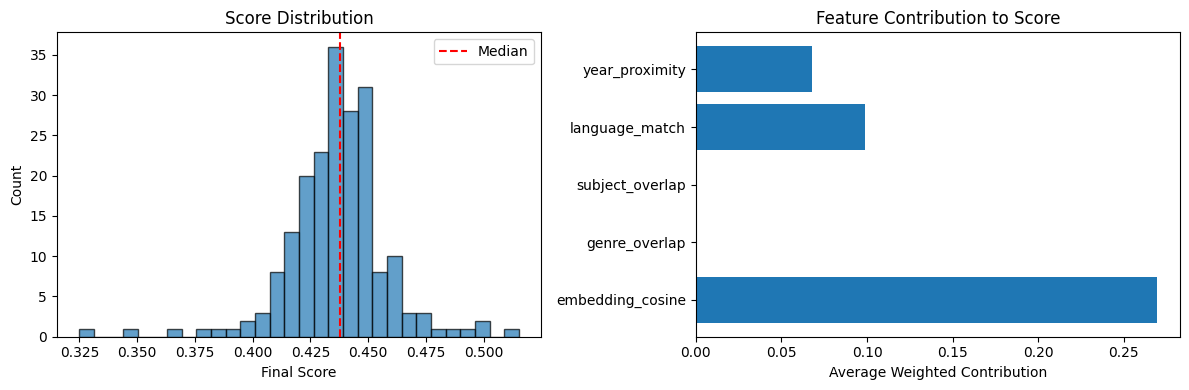

In [43]:
# Cell: Visualize score distribution
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Score distribution
axes[0].hist(ranked_candidates["final_score"], bins=30, edgecolor='black', alpha=0.7)
axes[0].set_xlabel("Final Score")
axes[0].set_ylabel("Count")
axes[0].set_title("Score Distribution")
axes[0].axvline(ranked_candidates["final_score"].median(), color='red', linestyle='--', label='Median')
axes[0].legend()

# Component contribution (average)
avg_contributions = {
    k: ranked_candidates[f"score_{k}"].mean() * v 
    for k, v in SCORING_WEIGHTS.items()
}
axes[1].barh(list(avg_contributions.keys()), list(avg_contributions.values()))
axes[1].set_xlabel("Average Weighted Contribution")
axes[1].set_title("Feature Contribution to Score")

plt.tight_layout()
plt.show()